In [1]:
cd ../..

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
%run run.py connect

2024-11-22 13:17:25,331::INFO::settings.py::Setting loglevel to INFO
2024-11-22 13:17:25,333::INFO::settings.py::Setting stores to {}
2024-11-22 13:17:25,334::INFO::settings.py::Setting database.misc.schema_prefix to 
2024-11-22 13:17:25,334::INFO::settings.py::Setting database.misc.create_tables to True
2024-11-22 13:17:25,335::INFO::settings.py::Setting enable_python_native_blobs to True
2024-11-22 13:17:25,336::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2024-11-22 13:17:25,338::INFO::settings.py::Setting database.user to thomas
2024-11-22 13:17:25,340::INFO::settings.py::Setting database.password to thomas
2024-11-22 13:17:25,400::INFO::connection.py::Connected thomas@128.178.51.167:3309
2024-11-22 13:17:25,415::INFO::table.py::could not log event in table ~log


Connecting thomas@128.178.51.167:3309


2024-11-22 13:17:25,831::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,831::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,843::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,843::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,866::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,866::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,894::INFO::table.py::could not log event in table ~log
2024-11-22 13:17:25,894::INFO::table.py::could not log event in table ~log


In [65]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM 
#import pingouin as pg
from scipy.stats import ttest_rel, ttest_ind
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/Figure2/"

In [4]:
# add sessions to groups table for easily pulling sessions
dual_occuder = [{"dataset": "Nightingale_2024-08-14_1"},
                {"dataset": "Nightingale_2024-08-13_1"},
                {"dataset": "Nightingale_2024-08-12_1"},
                {"dataset": "Nightingale_2024-08-11_1"},
                {"dataset": "Nightingale_2024-08-10_1"},
                {"dataset": "Lemming_2024-08-13_1"},
                {"dataset": "Lemming_2024-08-12_1"},
                {"dataset": "Lemming_2024-08-11_1"},
                {"dataset": "Lemming_2024-08-10_1"},
                {"dataset": "Jacana_2024-08-13_1"},
                {"dataset": "Jacana_2024-08-14_1"},
                {"dataset": "Jacana_2024-08-15_1"},
                {"dataset": "Jacana_2024-08-16_1"},
                {"dataset": "Jacana_2024-08-19_1"},
                {"dataset": "Kiwi_2024-08-10_2"},
                {"dataset": "Kiwi_2024-08-11_4"},
                {"dataset": "Kiwi_2024-08-12_2"},
                {"dataset": "Kiwi_2024-08-13_1"},
                {"dataset": "Kiwi_2024-08-14_1"},
                {"dataset": "Oribi_2024-08-16_1"},
                {"dataset": "Oribi_2024-08-19_1"},
                {"dataset": "Oribi_2024-08-20_1"},
                {"dataset": "Oribi_2024-08-21_1"},
                {"dataset": "Oribi_2024-08-22_1"},
                {"dataset": "Pheasant_2024-08-15_2"},
                {"dataset": "Pheasant_2024-08-16_1"},
                {"dataset": "Pheasant_2024-08-20_1"},
                {"dataset": "Pheasant_2024-08-21_1"},
               ]

print(len(dual_occuder))

28


# Pannel B - example trajectories 

In [5]:
# Load dataset and box positions

#df = DataFrame().get_data(key=dual_occuder[0], columns=["dataset", "reward", "x", "y", "trial", "aperture", "iti", "trial_left_choice", "trial_duration", "trial_tortuosity"])
#box_df = base_analysis.BoxDataFrame().get_data(key=dual_occuder[0])

#
df = DataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"}, columns=["dataset", "reward", "x", "y", "trial", "aperture", "iti", "trial_left_choice", "trial_duration", "trial_tortuosity"])
box_df = base_analysis.BoxDataFrame().get_data(key=dual_occuder[0])


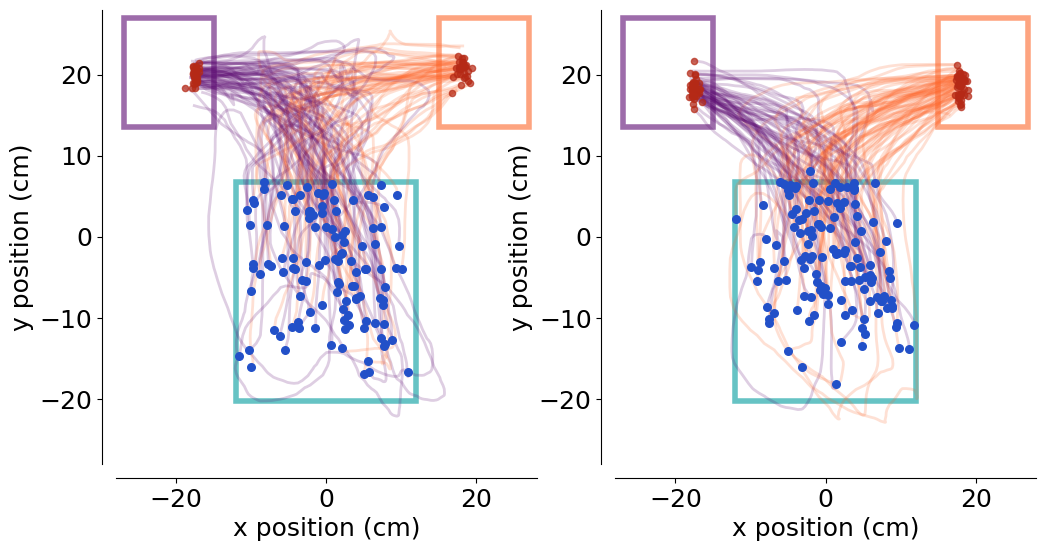

In [6]:
df = df [df.iti == 0.0]
j_shaped = analysis.get_jshaped_trials(df)

plotting.plot_session(
    df=j_shaped,
    box_df=box_df,
    per_aperture=True,
    per_side=True,
)
sns.despine(offset=10)
plt.savefig("notebooks/Paper_figures/Figure_output/example_session_trajectory_plot_dual_occluder_figure_2.svg", transparent=True)

In [7]:
def get_all_in_list(data_set_list, training_stage):
    print(training_stage)
    big_df = []
    
    for d in data_set_list:
        split_d = d["dataset"].split("_")
        print(split_d)
        
        offline_kinematics_df = dlc.OfflineKinematics().get_data(key=d, columns = ["head_center_x", "head_center_y", "heading_dir", "head_angle"])
        df = base_analysis.DataFrame().get_data(key=d, 
                                                        columns=[
                                                            'dataset', 'trial', 'aperture',
                                                            'trial_right_choice', 'trial_left_choice',
                                                            'velocity', 'velocity_x', 'velocity_y',
                                                            "reward",
                                                            'norm_y', "iti", "x", "y",
                                                            'trial_init_x', 'trial_init_y',
                                                            "trial_tortuosity", "trial_duration"
        ])
        df["trial_rewarded"] = base_analysis.DataFrame().get_rewarded(key=d)
        
        df = df.join(offline_kinematics_df)
        
        df["mouse_name"] = split_d[0]
        df["date"] = split_d[1]
        df["attempt"] = split_d[2]
        df["training_stage"] = training_stage
        
        big_df.append(df)
    
    big_df =  pd.concat(big_df).reset_index()
    big_df ["session_increment"] = np.array(big_df.groupby("dataset").ngroup()+1)
    big_df = big_df.infer_objects()
    
    return(big_df.reset_index(drop=True))

In [8]:
big_df = get_all_in_list(data_set_list=dual_occuder, training_stage="dual_occluder")

dual_occluder
['Nightingale', '2024-08-14', '1']
['Nightingale', '2024-08-13', '1']
['Nightingale', '2024-08-12', '1']
['Nightingale', '2024-08-11', '1']
['Nightingale', '2024-08-10', '1']
['Lemming', '2024-08-13', '1']
['Lemming', '2024-08-12', '1']
['Lemming', '2024-08-11', '1']
['Lemming', '2024-08-10', '1']
['Jacana', '2024-08-13', '1']
['Jacana', '2024-08-14', '1']
['Jacana', '2024-08-15', '1']
['Jacana', '2024-08-16', '1']
['Jacana', '2024-08-19', '1']
['Kiwi', '2024-08-10', '2']
['Kiwi', '2024-08-11', '4']
['Kiwi', '2024-08-12', '2']
['Kiwi', '2024-08-13', '1']
['Kiwi', '2024-08-14', '1']
['Oribi', '2024-08-16', '1']
['Oribi', '2024-08-19', '1']
['Oribi', '2024-08-20', '1']
['Oribi', '2024-08-21', '1']
['Oribi', '2024-08-22', '1']
['Pheasant', '2024-08-15', '2']
['Pheasant', '2024-08-16', '1']
['Pheasant', '2024-08-20', '1']
['Pheasant', '2024-08-21', '1']


2024-11-22 13:29:06,562::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:29:06,562::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:29:06,568::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:29:06,568::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:29:06,591::INFO::category.py::Using categorical un

wide occullusion mean:  0.8609187045415961 std:  0.07322276023567932
narrow occullusion mean:  0.796492935098228 std:  0.08084334730916194


TtestResult(statistic=3.9789523645975096, pvalue=0.00046789771285382615, df=27)

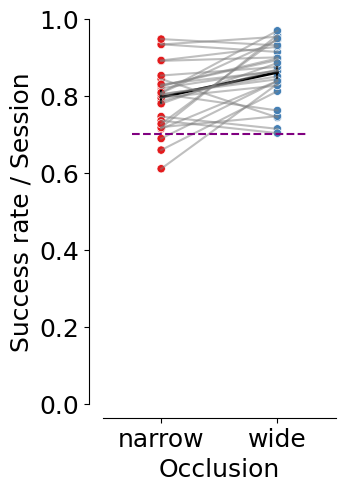

In [9]:

fig,ax = plt.subplots(1,1, figsize = (3,5))
counts = plotting.plot_rewards(df=big_df, ax=ax, alpha=0.5, per_aperture=True, cmap=plotting.colors_aperture[0:2][::-1])
plt.ylim(0,1.0)
plt.xlim(-0.5,1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Occlusion")
ax.set_xticks([0,1], ["narrow", "wide"])
sns.despine(offset=10)
plt.savefig(save_fig_path + "reward_success.svg", transparent=True)


counts = counts.pivot(index = "dataset", columns=["aperture"], values=["count"]) 
print("wide occullusion mean: ", np.mean(np.array(counts ["count"] ["12.0"])), "std: ",  np.std(np.array(counts ["count"] ["12.0"])))
print("narrow occullusion mean: ", np.mean(np.array(counts ["count"] ["4.3"])),  "std: ",  np.std(np.array(counts ["count"] ["4.3"])))
ttest_rel(np.array(counts ["count"] ["12.0"]),np.array(counts ["count"] ["4.3"]))

2024-11-22 13:49:46,029::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:49:46,029::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:49:46,035::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:49:46,035::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2024-11-22 13:49:46,081::INFO::category.py::Using categorical un

wide occullusion mean:  0.5038427185731487 std:  0.031658768556523956
narrow occullusion mean:  0.49615728142685134 std:  0.03165876855652396


TtestResult(statistic=0.6307052464152645, pvalue=0.5335359947917457, df=27)

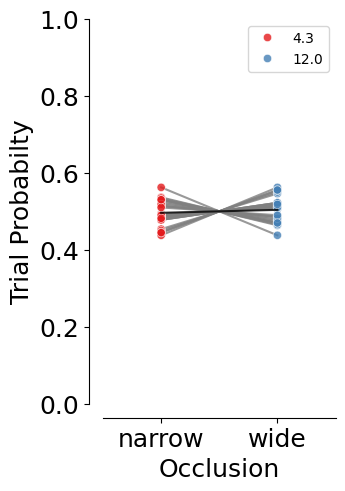

In [25]:
counts = big_df.groupby(["dataset", "aperture"]).trial.nunique().reset_index(name="trial_count")
    
    # Step 2: Calculate total trials per dataset
total_trials = big_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
    
    # Merge the counts and total_trials to calculate probabilities
counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts ["aperture"] = counts.aperture.astype("str")
    
    # Merge the counts and total_trials to calculate probabilities
fig,ax = plt.subplots(1,1, figsize = (3,5))

sns.lineplot(data=counts, x="aperture", y="probability", units="dataset", estimator=None, ax=ax,color="grey", alpha=0.8)
sns.scatterplot(data=counts, x="aperture", y="probability", hue="aperture", ax=ax,palette = plotting.colors_aperture, alpha=0.8, zorder=100)
sns.lineplot(data=counts, x="aperture", y="probability", ax=ax,color="black", err_style="bars",  alpha=0.8, zorder=120)
plt.ylim(0,1)
plt.xlim(-0.5,1.5)
plt.xticks([0,1], ["narrow", "wide"])

plt.xlabel("Occlusion")
plt.ylabel("Trial Probabilty")
sns.despine(offset=10)
plt.savefig(save_fig_path + "dual_occluder_trial_number.svg", transparent=True)

counts = counts.pivot(index = "dataset", columns=["aperture"], values=["probability"]) 
print("wide occullusion mean: ", np.mean(np.array(counts ["probability"] ["12.0"])), "std: ",  np.std(np.array(counts ["probability"] ["12.0"])))
print("narrow occullusion mean: ", np.mean(np.array(counts ["probability"] ["4.3"])),  "std: ",  np.std(np.array(counts ["probability"] ["4.3"])))
ttest_rel(np.array(counts ["probability"] ["12.0"]),np.array(counts ["probability"] ["4.3"]))

## Mean trajectory plots

In [11]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped =  analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

mean_mouse = j_shaped.groupby(
    ["dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=mean_mouse,
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-14, ymin=7.5, ymax=12.5, color="black", linewidth=2)
plt.hlines(y=7.5, xmin=-14, xmax=-5, color="black", linewidth=2)
plt.axis('off')
ax.legend(loc="lower right")
plt.savefig(save_fig_path + "mean_trajectory.svg", transparent =True)


NameError: name 'plt' is not defined

In [13]:
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
j_shaped ["x_flipped"] = j_shaped["x"]*j_shaped.flip_one_side
mean_mouse = j_shaped.groupby(
    ["dataset", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()



In [14]:
print(AnovaRM(data=mean_mouse, depvar='x_flipped', 
              subject='dataset', within=['aperture', "bin_centers"]).fit()) 

# TODO add post hocs - pingouin library, currently unable to install on this docker container

                        Anova
                     F Value   Num DF  Den DF  Pr > F
-----------------------------------------------------
aperture              67.7083  1.0000  27.0000 0.0000
bin_centers          247.1635 28.0000 756.0000 0.0000
aperture:bin_centers  14.1878 28.0000 756.0000 0.0000



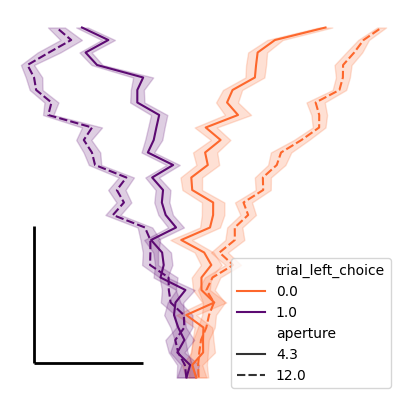

In [15]:
fig, ax = plt.subplots(1,1,figsize=(5,5))
plotting.lineplot_flip_axis(
    data=j_shaped [j_shaped.dataset ==  "Pheasant_2024-08-15_2"],
    x="bin_centers",
    y="x",
    hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
    palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else "viridis",
    style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
    errorbar="se",
    ax=ax,
)
plt.ylabel("y position")
plt.xlabel("x position")
plt.xlim(-16,16)
plt.vlines(x=-14, ymin=7.5, ymax=12.5, color="black", linewidth=2)

plt.hlines(y=7.5, xmin=-14, xmax=-5, color="black", linewidth=2)
#plt.arrow(-14, 7.5, 10, 0, head_width=.3, head_length=.5, linewidth=2, color='black', length_includes_head=True)
plt.axis('off')

ax.legend(loc="lower right")
plt.savefig(save_fig_path + "example_session_mean_trajectory.svg", transparent =True)


In [34]:
j_shaped["flip_one_side"] = j_shaped["trial_left_choice"].replace([0, 1], [1, -1])
big_df["flip_one_side"] = big_df["trial_left_choice"].replace([0, 1], [1, -1])
columns = [
    "y",
    "trial_tortuosity",
    "trial_duration",
    "x",
    "aperture",
    "velocity",
    "trial_rewarded",
    "flip_one_side",
]

interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=100, value_columns=["trial_left_choice"] + columns
)

interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["dataset", "trial"]
).trial.cumcount()
interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / 100




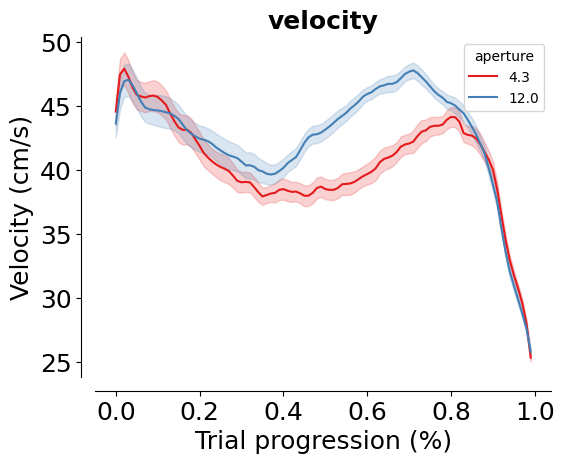

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y="velocity",
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else plotting.colors_aperture[:2]
        ),
        hue="aperture",
        errorbar="se",
        ax=ax,
    )
ax.set_title(f"{label}")
sns.despine(offset=10)
ax.set_xlabel("Trial progression (%)")
ax.set_ylabel("Velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "mean_veloctiy.svg", transparent =True)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              48.2510  1.0000   27.0000 0.0000
trial_length          67.5133 99.0000 2673.0000 0.0000
aperture:trial_length 20.0153 99.0000 2673.0000 0.0000



In [100]:
print(AnovaRM(data=mean_mouse, depvar='velocity', 
              subject='dataset', within=['aperture', "trial_length"]).fit()) 

p_values = []
for i in mean_mouse.trial_length.unique():
    section = mean_mouse [mean_mouse.trial_length==i]
    t= ttest_ind(section [section.aperture==section.aperture.unique()[0]].velocity, section [section.aperture==section.aperture.unique()[1]].velocity)
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))


                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              48.2510  1.0000   27.0000 0.0000
trial_length          67.5133 99.0000 2673.0000 0.0000
aperture:trial_length 20.0153 99.0000 2673.0000 0.0000



In [90]:
from scipy import stats

In [101]:
p_value_df = pd.concat(p_values)
p_value_df ["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

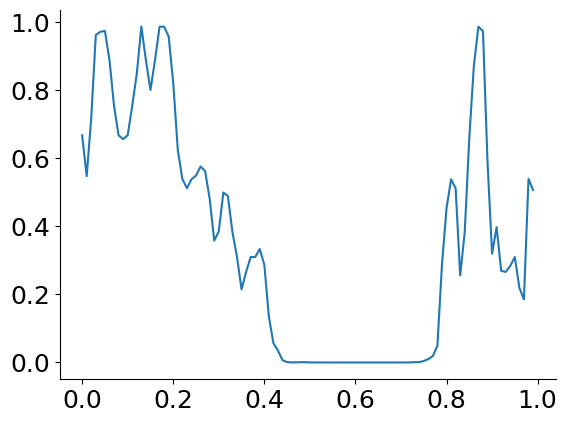

In [102]:
plt.plot(p_value_df.segment, p_value_df.p_value_corr)